# Tiền xử lý dữ liệu Biển báo giao thông

Notebook này xử lý dữ liệu **392 biển báo giao thông** từ file `traffic_signs_complete.json`.

**Mục tiêu:** Chuẩn hóa field `description` để phù hợp với hệ thống RAG:
- Lowercase
- Remove punctuation
- Tokenization (tách từ tiếng Việt)
- Không dùng gạch dưới (_) để tương thích với embedding models

## 1. Import thư viện

In [1]:
import json
from pathlib import Path
from underthesea import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## 2. Đọc dữ liệu biển báo

In [2]:
# Đường dẫn
BASE_DIR = Path(r"C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot")
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Đọc file
input_file = RAW_DIR / "traffic_signs_complete.json"
with open(input_file, 'r', encoding='utf-8') as f:
    signs_data = json.load(f)

print(f"✓ Đã load {len(signs_data)} biển báo từ: {input_file.name}")
print(f"\n5 biển báo đầu tiên:")
for i, sign in enumerate(signs_data[:5]):
    print(f"  {i+1}. {sign['name']}: {sign['description']}")

✓ Đã load 392 biển báo từ: traffic_signs_complete.json

5 biển báo đầu tiên:
  1. Biển P.101: Đường cấm
  2. Biển P.102: Cấm đi ngược chiều
  3. Biển P.103a: Cấm xe ô tô
  4. Biển P.103b: Cấm xe ô tô rẽ phải
  5. Biển P.103c: Cấm xe ô tô rẽ trái


## 3. Xem cấu trúc dữ liệu

In [3]:
# Sample record
sample = signs_data[0]
print("Cấu trúc 1 biển báo:")
print(json.dumps(sample, ensure_ascii=False, indent=2))

# Thống kê độ dài description
desc_lengths = [len(sign['description']) for sign in signs_data]
print(f"\nĐộ dài description:")
print(f"  Min: {min(desc_lengths)} ký tự")
print(f"  Max: {max(desc_lengths)} ký tự")
print(f"  Trung bình: {sum(desc_lengths)/len(desc_lengths):.1f} ký tự")

Cấu trúc 1 biển báo:
{
  "name": "Biển P.101",
  "description": "Đường cấm",
  "image_url": "https://upload.wikimedia.org/wikipedia/commons/thumb/5/5b/Vietnam_road_sign_P101.svg/250px-Vietnam_road_sign_P101.svg.png",
  "image_full_url": "https://upload.wikimedia.org/wikipedia/commons/5/5b/Vietnam_road_sign_P101.svg",
  "gallery_index": 0,
  "local_path": "traffic_signs_images\\Biển P.101.svg"
}

Độ dài description:
  Min: 0 ký tự
  Max: 96 ký tự
  Trung bình: 28.8 ký tự


## 4. Tiền xử lý description

Áp dụng các bước:
1. **Lowercase** - chuyển chữ thường
2. **Remove punctuation** - xóa dấu câu
3. **Tokenization** - tách từ tiếng Việt (KHÔNG dùng gạch dưới)

In [4]:
def preprocess_description(text):
    """
    Tiền xử lý description của biển báo.
    
    Args:
        text (str): Mô tả gốc
    
    Returns:
        str: Text đã xử lý (lowercase, no punctuation, tokenized)
    """
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove punctuation
    import re
    text = text.replace('/', ' ')
    text = re.sub(r'[^\w\s]', '', text)
    
    # 3. Tokenize (KHÔNG dùng format="text" để tránh gạch dưới)
    tokens = word_tokenize(text)
    text_tokenized = ' '.join(tokens)
    
    return text_tokenized

# Test với 1 mẫu
test_text = "Cấm xe ô tô, xe máy và các loại xe có động cơ"
print("Test tiền xử lý:")
print(f"  Trước: {test_text}")
print(f"  Sau:  {preprocess_description(test_text)}")

Test tiền xử lý:
  Trước: Cấm xe ô tô, xe máy và các loại xe có động cơ
  Sau:  cấm xe ô tô xe máy và các loại xe có động cơ


### 4.1. Áp dụng cho tất cả biển báo

In [5]:
# Xử lý tất cả
for sign in signs_data:
    sign['description_original'] = sign['description']  # Giữ bản gốc
    sign['description_processed'] = preprocess_description(sign['description'])

print(f"✓ Đã xử lý {len(signs_data)} biển báo")

# So sánh trước/sau
print("\nSo sánh 10 biển đầu tiên:")
print(f"{'Tên':<15} {'Original':<50} {'Processed':<50}")
print("="*115)
for sign in signs_data[:10]:
    print(f"{sign['name']:<15} {sign['description_original']:<50} {sign['description_processed']:<50}")

✓ Đã xử lý 392 biển báo

So sánh 10 biển đầu tiên:
Tên             Original                                           Processed                                         
Biển P.101      Đường cấm                                          đường cấm                                         
Biển P.102      Cấm đi ngược chiều                                 cấm đi ngược chiều                                
Biển P.103a     Cấm xe ô tô                                        cấm xe ô tô                                       
Biển P.103b     Cấm xe ô tô rẽ phải                                cấm xe ô tô rẽ phải                               
Biển P.103c     Cấm xe ô tô rẽ trái                                cấm xe ô tô rẽ trái                               
Biển P.104      Cấm xe máy                                         cấm xe máy                                        
Biển P.105      Cấm xe ô tô và xe máy                              cấm xe ô tô và xe máy                             
Biển 

## 5. Thống kê và khám phá dữ liệu

### 5.1. Thống kê từ vựng

In [6]:
# Tổng hợp tất cả token
all_tokens = []
for sign in signs_data:
    tokens = sign['description_processed'].split()
    all_tokens.extend(tokens)

# Đếm tần suất
word_freq = Counter(all_tokens)

print(f"📊 Thống kê:")
print(f"  Tổng số token: {len(all_tokens):,}")
print(f"  Số từ duy nhất: {len(word_freq):,}")
print(f"\nTop 20 từ xuất hiện nhiều nhất:")
for word, count in word_freq.most_common(20):
    print(f"  {word:<20} : {count:>3} lần")

📊 Thống kê:
  Tổng số token: 2,615
  Số từ duy nhất: 380

Top 20 từ xuất hiện nhiều nhất:
  đường                : 144 lần
  xe                   : 129 lần
  cấm                  :  61 lần
  hướng                :  48 lần
  biển                 :  45 lần
  cho                  :  43 lần
  phải                 :  40 lần
  đi                   :  39 lần
  rẽ                   :  38 lần
  giao                 :  36 lần
  bên                  :  33 lần
  có                   :  32 lần
  chỉ                  :  32 lần
  theo                 :  31 lần
  nhau                 :  31 lần
  trái                 :  30 lần
  tốc                  :  28 lần
  hết                  :  26 lần
  dành                 :  26 lần
  ô                    :  25 lần


### 5.2. Biểu đồ tần suất từ

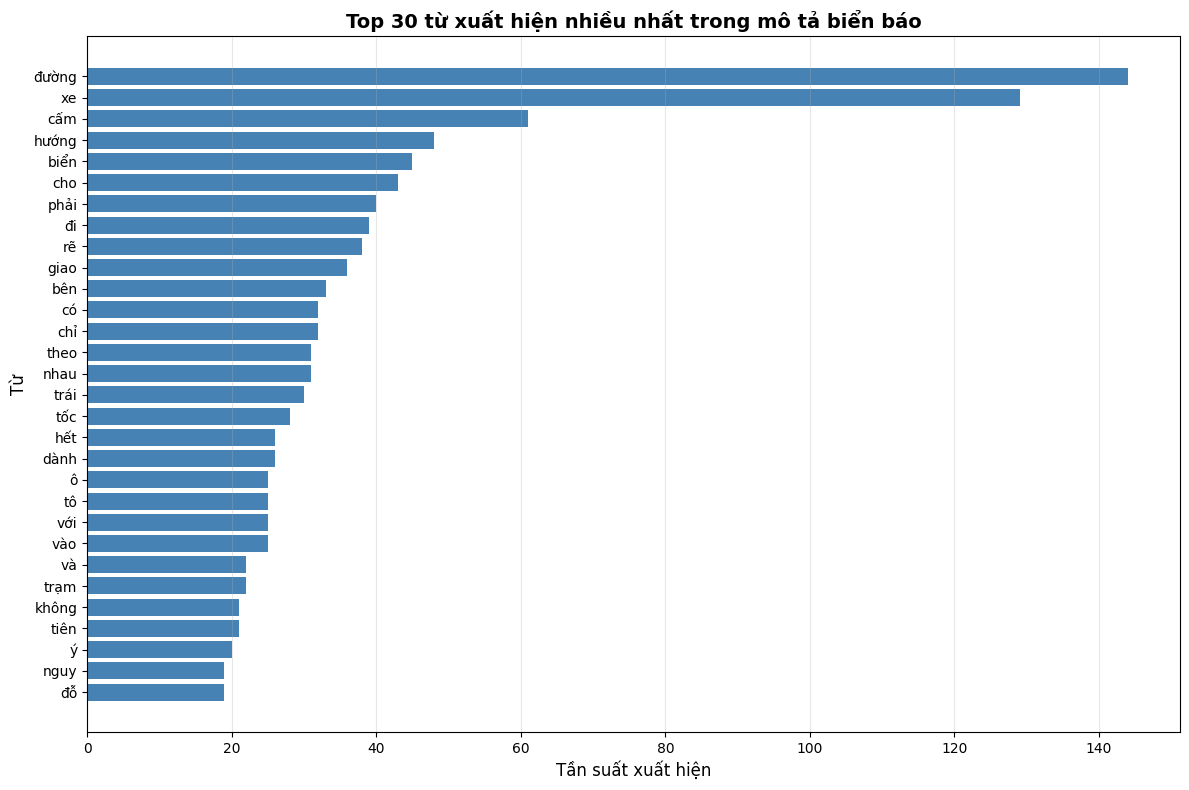

Biểu đồ hiển thị các từ khóa chính trong biển báo giao thông


In [7]:
# Lấy top 30 từ
top_words = word_freq.most_common(30)
words, counts = zip(*top_words)

# Vẽ biểu đồ ngang
plt.figure(figsize=(12, 8))
plt.barh(range(len(words)), counts, color='steelblue')
plt.yticks(range(len(words)), words, fontsize=10)
plt.xlabel('Tần suất xuất hiện', fontsize=12)
plt.ylabel('Từ', fontsize=12)
plt.title('Top 30 từ xuất hiện nhiều nhất trong mô tả biển báo', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Từ nhiều nhất ở trên
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Biểu đồ hiển thị các từ khóa chính trong biển báo giao thông")

### 5.3. Word Cloud

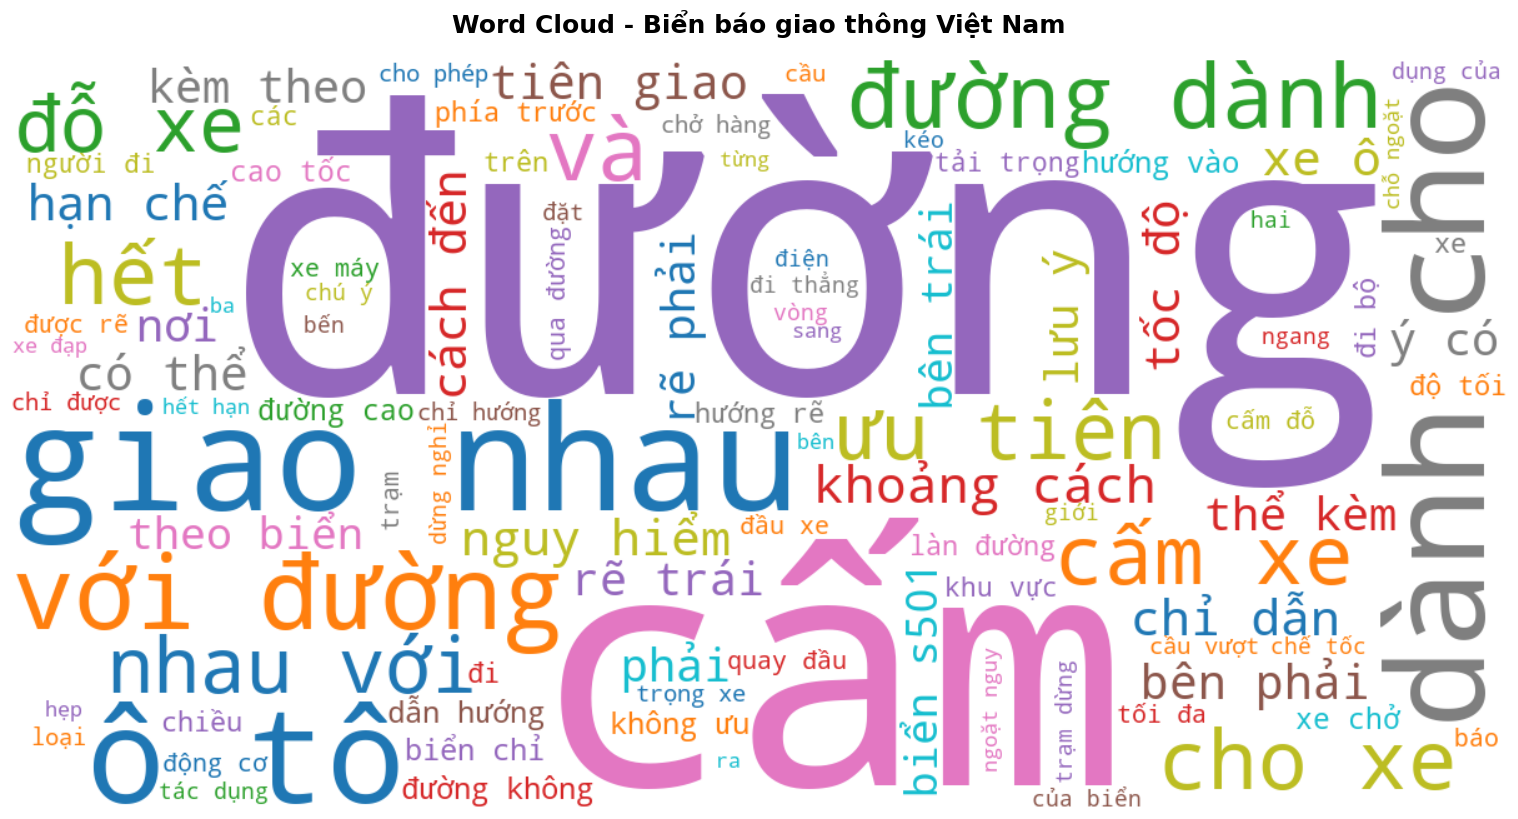

Word Cloud hiển thị các từ khóa phổ biến: cấm, xe, đường, tốc độ, ...


In [8]:
# Tạo text cho word cloud
text_for_cloud = ' '.join(all_tokens)

# Tạo Word Cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='tab10',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(text_for_cloud)

# Vẽ
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Biển báo giao thông Việt Nam', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout(pad=0)
plt.show()

print(f"Word Cloud hiển thị các từ khóa phổ biến: cấm, xe, đường, tốc độ, ...")

## 6. Phân loại biển báo theo nhóm

In [9]:
# Phân loại theo ký hiệu (P, R, W, I, S)
sign_types = {}
for sign in signs_data:
    prefix = sign['name'].split('.')[0].replace('Biển ', '')
    if prefix not in sign_types:
        sign_types[prefix] = []
    sign_types[prefix].append(sign['name'])

print("Phân loại biển báo theo nhóm:")
print(f"{'Nhóm':<10} {'Số lượng':<10} {'Ý nghĩa'}")
print("="*60)

meanings = {
    'P': 'Biển cấm',
    'R': 'Biển hiệu lệnh',
    'W': 'Biển cảnh báo',
    'I': 'Biển chỉ dẫn',
    'S': 'Biển phụ'
}

for prefix in sorted(sign_types.keys()):
    count = len(sign_types[prefix])
    meaning = meanings.get(prefix, 'Khác')
    print(f"{prefix:<10} {count:<10} {meaning}")

print(f"\nTổng: {sum(len(v) for v in sign_types.values())} biển báo")

Phân loại biển báo theo nhóm:
Nhóm       Số lượng   Ý nghĩa
           5          Khác
439        1          Khác
DP         8          Khác
I          94         Biển chỉ dẫn
IE         53         Khác
P          62         Biển cấm
R          56         Biển hiệu lệnh
S          24         Biển phụ
Vạch 6     1          Khác
Vạch 7     2          Khác
W          86         Biển cảnh báo

Tổng: 392 biển báo


## 7. Lưu kết quả

In [10]:
# Chuẩn bị dữ liệu output
output_data = {
    "metadata": {
        "total_signs": len(signs_data),
        "source_file": "traffic_signs_complete.json",
        "preprocessing_steps": [
            "1. Lowercase (chuyển chữ thường)",
            "2. Remove Punctuation (xóa dấu câu)",
            "3. Tokenization (tách từ tiếng Việt - không dùng gạch dưới)"
        ],
        "total_tokens": len(all_tokens),
        "unique_tokens": len(word_freq),
        "sign_categories": {k: len(v) for k, v in sign_types.items()}
    },
    "signs": []
}

# Thêm dữ liệu biển báo
for sign in signs_data:
    output_data["signs"].append({
        "name": sign['name'],
        "description_original": sign['description_original'],
        "description_processed": sign['description_processed'],
        "image_url": sign.get('image_url', ''),
        "local_path": sign.get('local_path', '')
    })

# Lưu file
output_file = PROCESSED_DIR / "traffic_signs_processed.json"
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

# Thống kê
file_size = output_file.stat().st_size / 1024  # KB

print(f"✅ ĐÃ LƯU KẾT QUẢ")
print(f"  📁 File: {output_file.name}")
print(f"  📍 Đường dẫn: {output_file}")
print(f"  📊 Số biển báo: {len(signs_data)}")
print(f"  💾 Kích thước: {file_size:.1f} KB")
print(f"\n🎯 File này đã sẵn sàng cho hệ thống RAG!")

✅ ĐÃ LƯU KẾT QUẢ
  📁 File: traffic_signs_processed.json
  📍 Đường dẫn: C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot\data\processed\traffic_signs_processed.json
  📊 Số biển báo: 392
  💾 Kích thước: 154.1 KB

🎯 File này đã sẵn sàng cho hệ thống RAG!
